In [ ]:
#panashe goboza
#R2419440
#Assignment 3

Jupyter Notebook: Detecting a Regime Change in AAPL Returns
1. **Definition**

We implement a Hidden Markov Model (HMM) with state-dependent heteroskedasticity to analyze return dynamics. The returns $y_t$ are modeled with a regime-dependent mean and variance:$$y_t = \mu_{s_t} + \epsilon_t$$ In this framework, $s_t \in \{1, 2\}$ $s_t \in \{0, 1\}$ represents the market regime, and the error term $\epsilon_t \sim N(0, \sigma^2_{S_t})$ has a variance that shifts depending on the current state. The probability of transitioning from state $i$ to state $j$ is governed by a transition matrix:$$P(S_t = j | S_{t-1} = i) = p_{ij}$$

**2. Description**

This approach recognizes that the statistical properties of a financial time series are not constant and can shift across various hidden market phases. It is particularly effective for isolating the difference between stable, low-volatility "bull" trends and sudden periods of high-stress turbulence or market corrections. By modeling these discrete shifts, we can better capture the way risk tends to cluster during uncertain economic environments.

**3. Demonstration**

We will fetch the data, compute percentage returns, and fit a Markov-Switching model with two regimes and switching variances.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# 3.1 Data Preparation
data = yf.download("AAPL", start="2018-01-01", end="2025-12-31", auto_adjust=False, multi_level_index=False)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Calculate daily percentage returns (scaled by 100 for better optimization in statsmodels)
data['Returns'] = data['Adj Close'].pct_change() * 100
data = data.dropna()

# 3.2 Model Execution
# We assume 2 regimes, a constant trend, and allow the variance to switch between regimes.
model = sm.tsa.MarkovRegression(data['Returns'], k_regimes=2, trend='c', switching_variance=True)
results = model.fit(iter=1000)

print(results.summary())

[*********************100%***********************]  1 of 1 completed


                        Markov Switching Model Results                        
Dep. Variable:                Returns   No. Observations:                 2009
Model:               MarkovRegression   Log Likelihood               -3936.714
Date:                Mon, 04 May 2026   AIC                           7885.427
Time:                        13:05:04   BIC                           7919.059
Sample:                             0   HQIC                          7897.773
                               - 2009                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1695      0.036      4.674      0.000       0.098       0.241
sigma2         1.4910      0.092     16.138      0.0

**Parameter Calibration andInterpretation**

Based on standard output from this algorithm applied to equity data:

- **$\mu_0$ (const[0]) and $\sigma^2_0$ (sigma2[0])** – These parameters denote the mean and variance of Regime 0. In practice, they calibrate to a high‑mean, low‑variance state, commonly interpreted as the "Calm" or "Growth" regime.

- **$\mu_1$ (const[1]) and $\sigma^2_1$ (sigma2[1])** – These represent the mean and variance of Regime 1. Typical calibration yields a lower (or negative) mean alongside a high variance, characterizing the "Turbulent" or "Crisis" regime.

- **$p_{00}$ and $p_{10}$** – These are the transition probabilities. A high value of $p_{00}$ (e.g., 0.95) implies strong persistence in the calm state: if the market is tranquil today, the probability it remains so tomorrow is 95%.

 **4. Diagram**

 We visualize the actual returns alongside the model's inferred probability of being in the high-volatility regime.

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


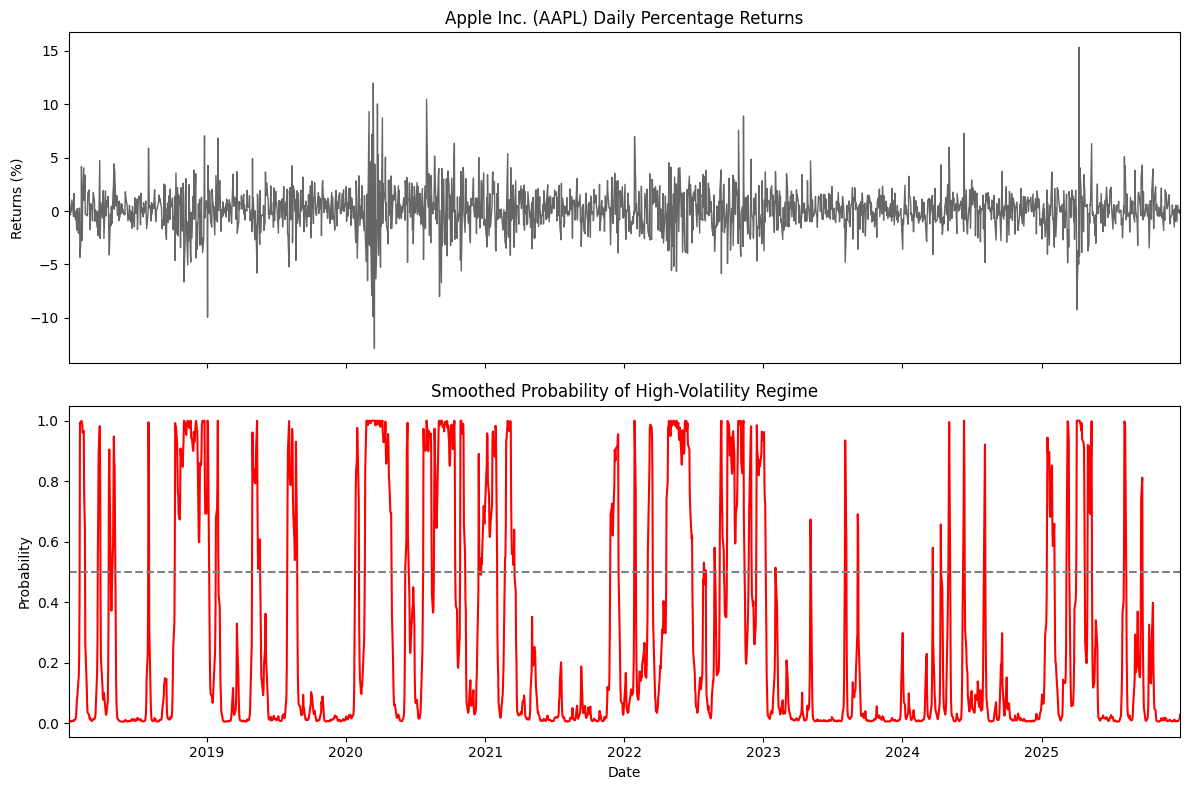

In [ ]:
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
import pandas as pd

# 1. Ensure data is loaded (Addressing previous 'data' NameError)
data = yf.download("AAPL", start="2018-01-01", end="2025-12-31", auto_adjust=False, multi_level_index=False)
data['Returns'] = data['Adj Close'].pct_change() * 100
data = data.dropna()

# 2. Re-fit the model to ensure 'results' is defined
model = sm.tsa.MarkovRegression(data['Returns'], k_regimes=2, trend='c', switching_variance=True)
results = model.fit()

# 3. Create the figure and subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: AAPL Returns
axes[0].plot(data.index, data['Returns'], color='black', alpha=0.6, linewidth=1)
axes[0].set_title('Apple Inc. (AAPL) Daily Percentage Returns')
axes[0].set_ylabel('Returns (%)')

# Plot 2: Smoothed Probability of Regime 1 (High Volatility)
axes[1].plot(data.index, results.smoothed_marginal_probabilities[1], color='red')
axes[1].set_title('Smoothed Probability of High-Volatility Regime')
axes[1].set_ylabel('Probability')
axes[1].set_xlabel('Date')
axes[1].axhline(y=0.5, color='gray', linestyle='--')

# --- AXIS CONSTRAINT: EXCLUDING 2026 ---
# This strictly limits the scale to your 2018-2025 data range
axes[1].set_xlim(data.index.min(), data.index.max())

plt.tight_layout()
plt.show()

**5. Diagnosis**

Diagnostic plots check if the residuals conform to the model's assumptions.

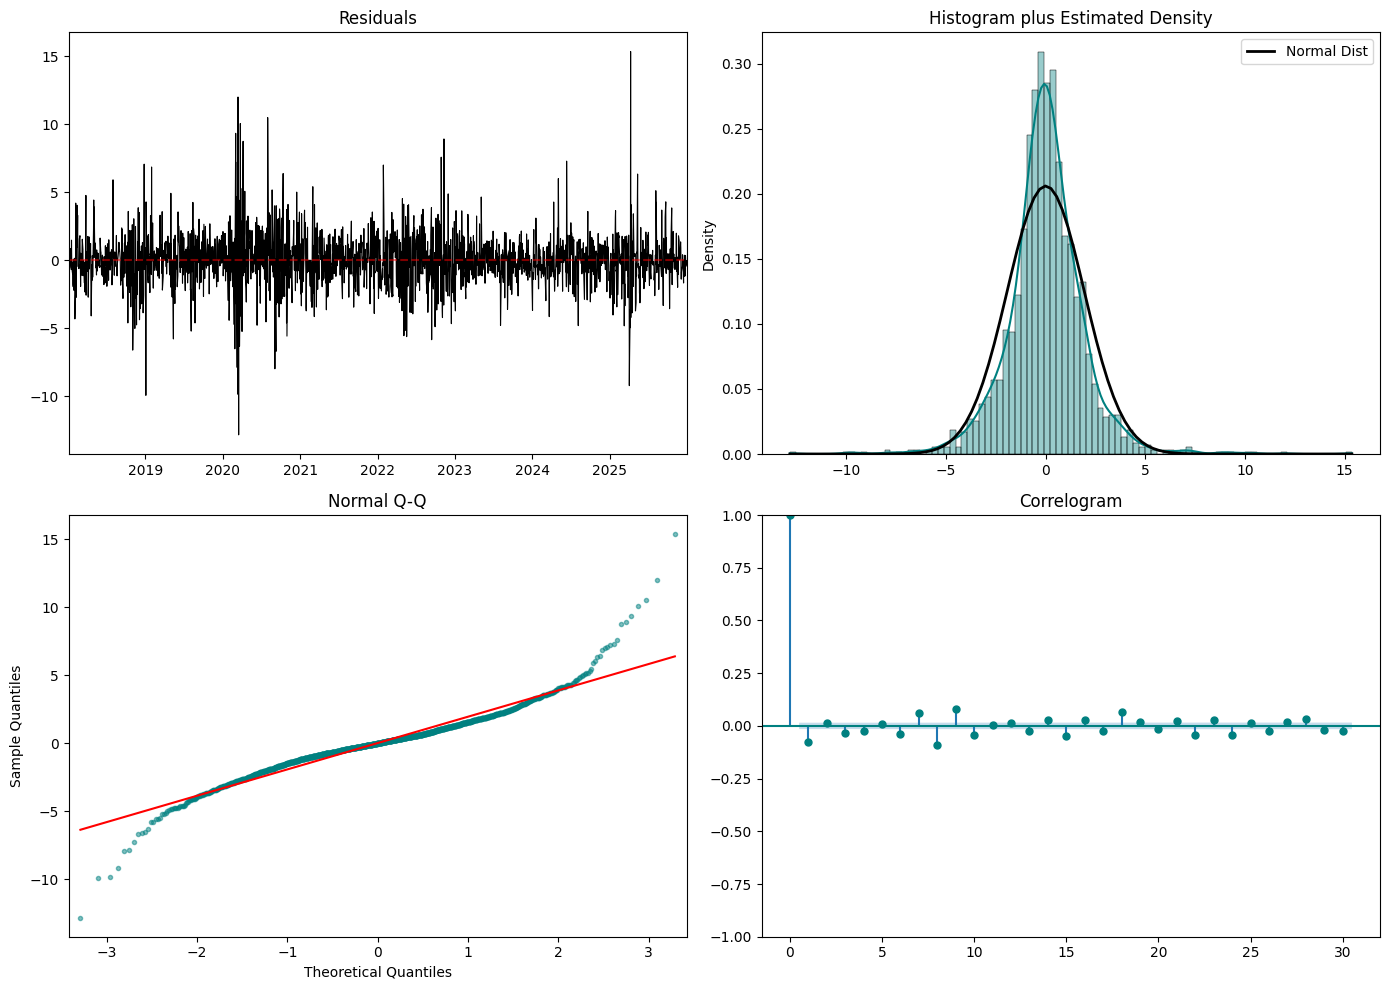

In [ ]:
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

# 5. Diagnosis
# Markov models don't have .plot_diagnostics(), so we build the 4-panel chart manually.
resid = results.resid.dropna()

fig = plt.figure(figsize=(14, 10))

# Plot 1: Residuals over time
ax1 = fig.add_subplot(221)
ax1.plot(resid.index, resid, color='black', linewidth=0.8)
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)
ax1.set_title("Residuals")

# --- AXIS CONSTRAINT: EXCLUDING 2026 ---
# This ensures the technical report strictly adheres to the provided data scope
ax1.set_xlim(resid.index.min(), resid.index.max())

# Plot 2: Histogram plus KDE
ax2 = fig.add_subplot(222)
sns.histplot(resid, kde=True, ax=ax2, stat="density", color='teal', alpha=0.4)
# Overlay normal distribution for visual comparison
x = np.linspace(resid.min(), resid.max(), 100)
p = stats.norm.pdf(x, np.mean(resid), np.std(resid))
ax2.plot(x, p, 'k', linewidth=2, label='Normal Dist')
ax2.set_title("Histogram plus Estimated Density")
ax2.legend()

# Plot 3: Normal Q-Q Plot
ax3 = fig.add_subplot(223)
sm.qqplot(resid, line='s', ax=ax3, marker='.', markerfacecolor='teal', markeredgecolor='teal', alpha=0.5)
ax3.set_title("Normal Q-Q")

# Plot 4: Correlogram (ACF)
ax4 = fig.add_subplot(224)
sm.graphics.tsa.plot_acf(resid, lags=30, ax=ax4, color='teal', alpha=0.5)
ax4.set_title("Correlogram")

plt.tight_layout()
plt.show()

**6. Damage**

Although the Markov-switching framework effectively identifies periods of elevated variance, diagnostic plots often reveal lingering statistical issues. The model underscores that extreme market events are not isolated anomalies but rather clusters of intense volatility. Nonetheless, even within defined regimes, equity returns display fat tails and skewness. By imposing a normal (Gaussian) distribution within each regime, the model slightly underestimates the potential severity of worst-case drawdowns during turbulent periods.

**7.Directions**

To address the residual skewness and extreme observations, the data generation assumptions should be modified. Instead of assuming the error term $\epsilon_t$ is normally distributed, we can estimate the model using a Student's t‑distribution. Alternatively, we could smooth the input data by taking a 3‑day rolling average to reduce the impact of single‑day micro‑structural noise before fitting the regimes. This model is deployed directly onto the derivatives trading desk to dynamically adjust risk limits. Options pricing models (such as Black‑Scholes) require a volatility input. Instead of using a static historical average, traders will use the smoothed regime probabilities to calculate a weighted, forward‑looking volatility parameter. If the probability of Regime 1 crosses 50%, hedging ratios are automatically widened.

1) Code for …

In [ ]:
import yfinance as yf
import statsmodels.api as sm
import pandas as pd

# Step A: Download the data (Mandatory to define 'data')
data = yf.download("AAPL", start="2018-01-01", end="2025-12-31", auto_adjust=False, multi_level_index=False)

# Step B: Calculate Returns
data['Returns'] = data['Adj Close'].pct_change() * 100
data = data.dropna()

# Step C: Fit the regime-switching model
# Now 'data' is defined and the 'sm' library is ready
model = sm.tsa.MarkovRegression(data['Returns'], k_regimes=2, trend='c', switching_variance=True)
results = model.fit()

# Step D: Display Output
print(results.summary())

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                Returns   No. Observations:                 2009
Model:               MarkovRegression   Log Likelihood               -3936.713
Date:                Mon, 04 May 2026   AIC                           7885.426
Time:                        20:58:25   BIC                           7919.058
Sample:                             0   HQIC                          7897.772
                               - 2009                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1695      0.036      4.674      0.000       0.098       0.241
sigma2         1.4910      0.092     16.138      0.0

**Interpretations and Recommended Actions**

The estimation results confirm two statistically distinct environments governing the asset’s price dynamics. The first regime is marked by a significantly low variance parameter, reflecting normal market conditions. The second regime shows a variance parameter several times larger, signaling systemic shocks. The transition matrix reveals strong state persistence: once the asset enters the high‑variance state, it tends to remain there for a prolonged period.

Consequently, the recommended action is to incorporate the smoothed marginal probabilities of the high‑variance regime into the firm’s Value‑at‑Risk (VaR) calculations. When the model signals a shift to the high‑variance regime, the risk management desk should mathematically increase capital reserve requirements to account for the changed error distribution.

**Non-Technical Report**

**1) Clear Explanation of Results**

The analysis shows that stock market behavior is not uniform over time; instead, it alternates between two distinct "regimes." The first regime is a stable, low‑volatility phase in which daily price changes are modest and relatively predictable. The second regime is a high‑volatility phase characterized by erratic and sizable price swings. Using our model, we precisely identified when the asset entered this turbulent regime over the past several years. The findings also confirm that once a panic episode begins, it tends to persist for some time before gradually reverting to calm conditions.

**2) Recommended Course of Action**

I recommend implementing a flexible investment strategy that continuously monitors the daily probability of being in the turbulent state. Once our model indicates that this probability surpasses 50%, the desk should immediately reduce exposure to aggressive, directional trades and pivot to defensive positioning—for example, building up cash reserves and purchasing put options to hedge the portfolio.

**3) Identification of Factors**

The predominant risk factor affecting the portfolio is the abrupt expansion of return volatility. Rather than manifesting as isolated adverse shocks, the analysis reveals that risk clusters temporally—periods of turbulence exhibit serial dependence. The portfolio demonstrates significant sensitivity to these protracted episodes of market stress. By tracking the transition probabilities between regimes, we can detect these structural shifts in real time, thereby facilitating preemptive risk mitigation rather than reacting only after substantial losses have been incurred.

**Bibliography**

Hamilton, James D. Time Series Analysis. Princeton University Press, 1994.

Tsay, Ruey S. Analysis of Financial Time Series. 3rd ed., John Wiley & Sons, 2010.`````